# *Advertising Sales Prediction Using Linear Regression*

## *Project Overview :*

This project uses Linear Regression to predict product sales based on
advertising expenditure across different media channels.

The project demonstrates a basic machine learning workflow, including
data exploration, feature selection, model training, prediction, and
model evaluation.


---



## **1. Import Libraries :**

The required Python libraries are imported for data manipulation,
visualization, machine learning, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(
    'ignore' , category=UserWarning,module="skleatn.utils.validations"
    )
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score , mean_squared_error

## **2. Load the Dataset :**

The Advertising dataset is loaded into a pandas DataFrame for
exploration and analysis.

In [2]:
df = pd.read_csv("advertising.csv")

## **3. Initial Dataset Inspection :**

The dataset is inspected to understand its structure, features,
data types, and basic statistical information.

In [3]:
df.shape

(200, 4)

In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
df.nunique().sum()

np.int64(650)

In [9]:
df.value_counts().sum()

np.int64(200)

In [10]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


## **4. Exploratory Data Analysis ;**

Exploratory Data Analysis (EDA) is performed to understand the
relationships between advertising expenditure and sales before
training the machine learning model.

In [11]:
corelation = df.corr(numeric_only=True)


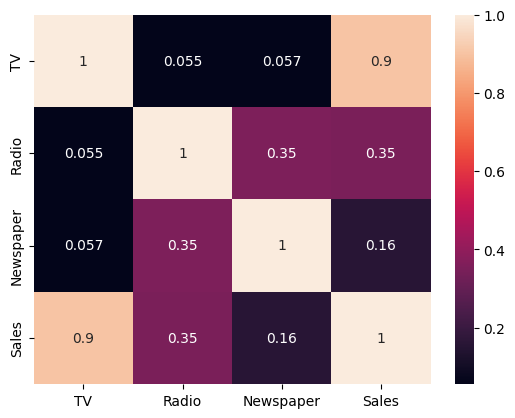

In [12]:
sns.heatmap(corelation,annot=True)
plt.show()

# **TV Advertizing Vs Sales**

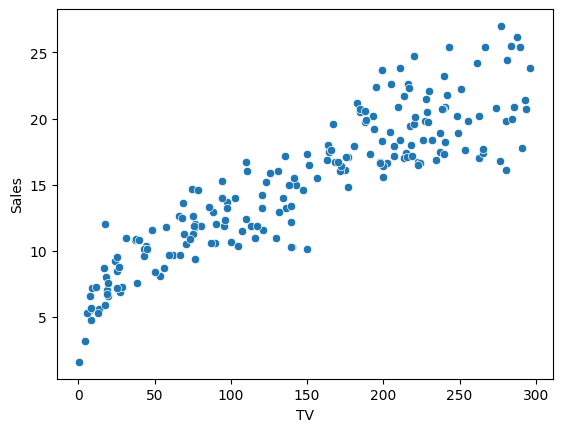

In [13]:
sns.scatterplot(x="TV",y="Sales",data=df)
plt.show()

# **Radio Advertizing VS Sales**

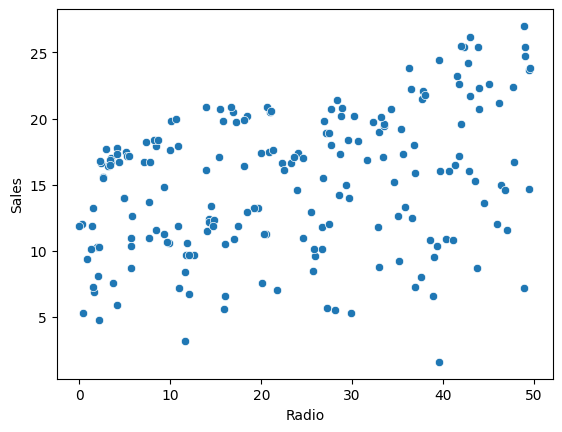

In [14]:
sns.scatterplot(x="Radio",y="Sales",data=df)
plt.show()

# **Newspaper Advertizing VS Sales**

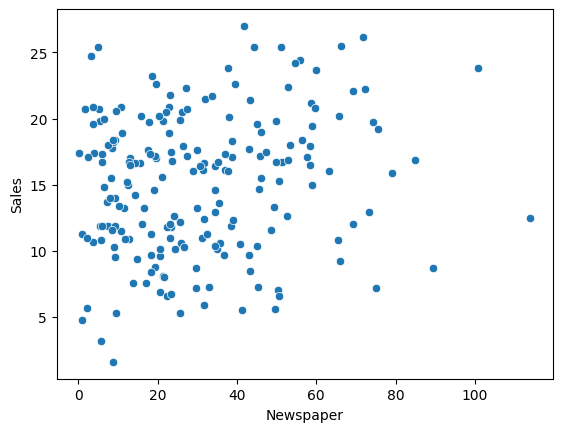

In [15]:
sns.scatterplot(x="Newspaper",y="Sales",data=df)
plt.show()

## **5. Define Features and Target :**

The input features (X) represent advertising expenditure, while the
target variable (y) represents product sales that the model will
learn to predict.

In [16]:
X = df[['Newspaper','Radio','TV']]
y = df['Sales']

In [17]:
X.head()

,Newspaper,Radio,TV
0,69.2,37.8,230.1
1,45.1,39.3,44.5
2,69.3,45.9,17.2
3,58.5,41.3,151.5
4,58.4,10.8,180.8


In [18]:
y.head()

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


## **6. Train-Test Split :**

The dataset is divided into training and testing sets.

The training data is used to train the Linear Regression model, while
the testing data is used to evaluate its performance on unseen data.

In [19]:
X_train , X_test , y_train , y_test =train_test_split (
    X,y,test_size=0.2,random_state=42
)

## **7. Create the Linear Regression Model :**

Linear Regression is used to learn the relationship between the
advertising features and product sales.

In [20]:
model = LinearRegression()


## **8. Train the Model :**

The Linear Regression model is trained using the training data.
During training, the model learns the relationship between the
advertising features and sales.

In [21]:
model.fit(X_train,y_train)

LinearRegression()

## **9. Make Predictions :**

The trained model is used to predict sales for the test dataset.

In [22]:
y_pred = model.predict(X_test)
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Newspaper,0.004337
1,Radio,0.100945
2,TV,0.054509


## **10. Model Evaluation :**

The model is evaluated using Mean Absolute Error (MAE), Mean Squared
Error (MSE), and R² Score.

These metrics help us understand how closely the predicted sales
values match the actual sales values.

In [24]:
mae = mean_absolute_error(y_test,model.predict(X_test))
r2 = r2_score(y_test,model.predict(X_test))
mse = mean_squared_error(y_test,model.predict(X_test))
rmse = np.sqrt(mse)


In [25]:
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 1.27
MSE: 2.91
RMSE: 1.71
R²: 0.91


### **Actual vs Predicted Sales**
The following visualization compares the actual sales values with
the values predicted by the Linear Regression model.

In [26]:
result_df = pd.DataFrame({
    "Actual_Values" : y_test,
    "Predicted_Values" : model.predict(X_test)
})
result_df.head()

,Actual_Values,Predicted_Values
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


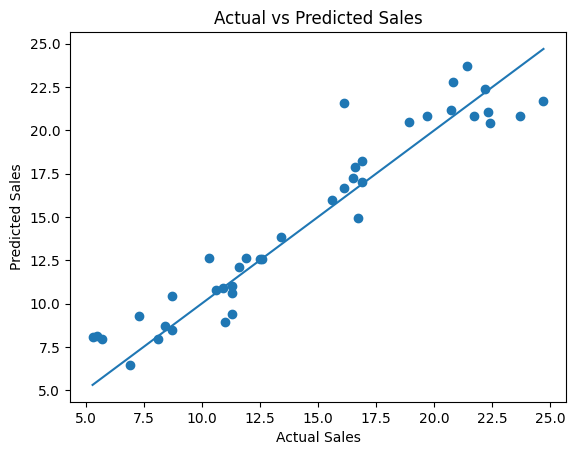

In [27]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

# **Residuals :**

It is the difference between an observed (actual) value and the value predicted by a model.

A positive residual means the model underestimated the true value (y > ŷ), while a negative residual means the model overestimated it (y < ŷ).

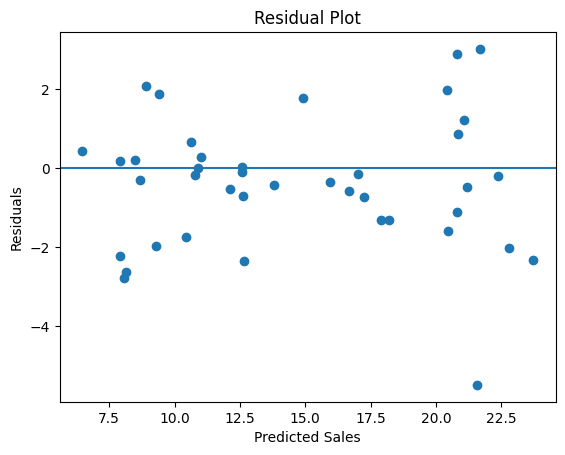

In [28]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# **Trying On New Data**

In [29]:
new_data = pd.DataFrame({
    "TV": [150,200],
    "Radio": [30,40],
    "Newspaper": [20,30]
})

In [30]:
new_data = new_data[X.columns] # Reorder columns to match the training data
prediction = model.predict(new_data)
print(f"Predicted Sales: {prediction[0]:.2f}")

Predicted Sales: 16.01


In [31]:
new_data2 = pd.DataFrame({
    "TV": [200, 130, 270],
    "Radio": [40, 25, 50],
    "Newspaper": [30, 15, 60]
})
new_data2 = new_data[X.columns]
predictions = model.predict(new_data)

print(predictions)

[16.00561084 19.78389447]


## **12. Conclusion :**

In this project, Linear Regression was used to predict product sales
from advertising expenditure.

The project provided practical experience with data exploration,
feature and target selection, train-test splitting, model training,
prediction, and model evaluation.

This project represents an introductory application of supervised
machine learning using Linear Regression.